# Estoque que Mente: Classificação ABC-XYZ + Política de Reposição Segmentada

> **Série: Data Science no Mundo Real — Episódio 1**  
> Acompanha o post completo no Medium: [link]

## Objetivo
Demonstrar como a segmentação ABC-XYZ, combinada com cálculo de estoque de segurança por perfil de demanda, reduz rupturas sem aumentar proporcionalmente o capital imobilizado.

## Estrutura do notebook
1. Coleta de dados - Kaggle - https://www.kaggle.com/competitions/m5-forecasting-accuracy
2. Análise exploratória
3. Classificação ABC-XYZ
4. Visualização estratégica
5. Cálculo de ponto de reposição por segmento
6. Simulação de impacto: política atual × política segmentada
7. Resumo executivo

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
import gc

warnings.filterwarnings('ignore')

# Estilo visual
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False
})

np.random.seed(42)
print('Setup concluído.')

Setup concluído.


## 1. Coleta de dados do Kaggle

Link: https://www.kaggle.com/competitions/m5-forecasting-accuracy

Dados hierárquicos de vendas diárias do Walmart em 3 estados americanos (Califórnia, Texas e Wisconsin), cobrindo itens individuais, departamentos, categorias de produto e lojas.  
Além do volume de vendas, o dataset inclui variáveis explicativas como preço, promoções, dia da semana e eventos especiais.   
Cenário mais próximo do que se encontra em operações reais de varejo e supply chain.

In [2]:
# import kagglehub

# # Download latest version
# path = kagglehub.competition_download('m5-forecasting-accuracy')

# print("Path to competition files:", path)

In [3]:
base = '/home/giovane/.cache/kagglehub/competitions/m5-forecasting-accuracy'

calendar = pd.read_csv(f'{base}/calendar.csv') # Contains information about the dates on which the products are sold.
prices = pd.read_csv(f'{base}/sell_prices.csv') # Contains information about the price of the products sold per store and date.
sales = pd.read_csv(f'{base}/sales_train_validation.csv') #Contains the historical daily unit sales data per product and store [d_1 - d_1913]


In [4]:
calendar.head(20)
#wm_yr_wk --> Walmart year week
#snap --> benefício liberado (sim = 1 e não = 0)

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1
5,2011-02-03,11101,Thursday,6,2,2011,d_6,NaN,NaN,NaN,NaN,1,1,1
6,2011-02-04,11101,Friday,7,2,2011,d_7,NaN,NaN,NaN,NaN,1,0,0
7,2011-02-05,11102,Saturday,1,2,2011,d_8,NaN,NaN,NaN,NaN,1,1,1
8,2011-02-06,11102,Sunday,2,2,2011,d_9,SuperBowl,Sporting,NaN,NaN,1,1,1
9,2011-02-07,11102,Monday,3,2,2011,d_10,NaN,NaN,NaN,NaN,1,1,0


In [5]:
calendar['d'] = calendar['d'].astype('category')

O que preciso aqui? 
* Receita por cada SKU olhando para todas as lojas

Tenho 10 lojas no total e 3049 produtos.   
As vendas estão distribuídas em 1906 dias diferentes e 282 semanas cada uma com um preço diferente.  
O preço é dado com a chave loja-semana. 

Para não estourar a memória de processamento, preciso seguir os próximos passos:
  1. criar uma tabela para cada loja com item_id | store_id (cte) | d | qty --> df_tot_sales
  2. Nessa tabela, conectar a informação do calendário com o wm_yr_wk para cada d (day)
  3. Conectar a tabela de price e valorar cada item_id | wm_yr_wk
  4. Agregar a tabela por item_id | store_id (cte) | d --> sum(qty)
  5. Por fim, repetir para outras lojas, concatenar as tabelas e, se quiser, fazer a agregação apenas por produto. 

In [6]:
sales.drop(columns='id',inplace=True)

In [7]:
lista_dfs = []

for i in prices['store_id'].unique():
    print(f'{i} - Processamento iniciado')
    sales_sample = sales[sales['store_id'] == i].copy()
    sales_long = sales_sample.melt(
        id_vars=['item_id', 'store_id', 'dept_id', 'cat_id', 'state_id'],
        var_name='d',
        value_name='demanda'
    )
    for col in ['item_id', 'store_id', 'dept_id', 'cat_id', 'state_id', 'd']:
        sales_long[col] = sales_long[col].astype('category').cat.remove_unused_categories()
    sales_long['demanda'] = pd.to_numeric(sales_long['demanda'], downcast='integer')
    del sales_sample

    sales_long_2 = sales_long.merge(calendar[['d', 'wm_yr_wk']], on='d', how='left')
    del sales_long

    sales_long_3 = sales_long_2.groupby(
        ['item_id', 'store_id', 'dept_id', 'cat_id', 'state_id', 'wm_yr_wk'],
        observed=True, as_index=False
    )['demanda'].sum()
    del sales_long_2

    sales_long_4 = sales_long_3.merge(prices[['wm_yr_wk', 'item_id', 'sell_price']], on=['wm_yr_wk', 'item_id'], how='left')
    sales_long_4['receita'] = sales_long_4['demanda'] * sales_long_4['sell_price']
    del sales_long_3

    sales_long_5 = sales_long_4.drop(columns=['wm_yr_wk', 'sell_price'])
    for col in ['item_id', 'store_id', 'dept_id', 'cat_id', 'state_id']:
        sales_long_5[col] = sales_long_5[col].astype('category')
    del sales_long_4

    df_tot_sales = sales_long_5.groupby(
        ['item_id', 'store_id', 'dept_id', 'cat_id', 'state_id'],
        observed=True, as_index=False
    )[['receita', 'demanda']].sum()

    lista_dfs.append(df_tot_sales)
    print(f'{i} - Processamento finalizado')

df_total_sales = pd.concat(lista_dfs, ignore_index=True)

CA_1 - Processamento iniciado
CA_1 - Processamento finalizado
CA_2 - Processamento iniciado
CA_2 - Processamento finalizado
CA_3 - Processamento iniciado
CA_3 - Processamento finalizado
CA_4 - Processamento iniciado
CA_4 - Processamento finalizado
TX_1 - Processamento iniciado
TX_1 - Processamento finalizado
TX_2 - Processamento iniciado
TX_2 - Processamento finalizado
TX_3 - Processamento iniciado
TX_3 - Processamento finalizado
WI_1 - Processamento iniciado
WI_1 - Processamento finalizado
WI_2 - Processamento iniciado
WI_2 - Processamento finalizado
WI_3 - Processamento iniciado
WI_3 - Processamento finalizado


In [8]:
df_total_sales.head()

,item_id,store_id,dept_id,cat_id,state_id,receita,demanda
0,HOBBIES_1_001,CA_1,HOBBIES_1,HOBBIES,CA,49641.64,5992
1,HOBBIES_1_002,CA_1,HOBBIES_1,HOBBIES,CA,19546.31,4924
2,HOBBIES_1_003,CA_1,HOBBIES_1,HOBBIES,CA,8270.06,2790
3,HOBBIES_1_004,CA_1,HOBBIES_1,HOBBIES,CA,149248.62,32858
4,HOBBIES_1_005,CA_1,HOBBIES_1,HOBBIES,CA,52955.12,18387


In [9]:
#Convertendo os nomes das colunas para Português
df_total_sales.rename(columns={
                            'item_id': 'sku',
                            'store_id':'loja',
                            'dept_id':'departamento',
                            'cat_id':'categoria',
                            'state_id':'estado'
                            },inplace=True)

In [10]:
df_total_sales.head()

,sku,loja,departamento,categoria,estado,receita,demanda
0,HOBBIES_1_001,CA_1,HOBBIES_1,HOBBIES,CA,49641.64,5992
1,HOBBIES_1_002,CA_1,HOBBIES_1,HOBBIES,CA,19546.31,4924
2,HOBBIES_1_003,CA_1,HOBBIES_1,HOBBIES,CA,8270.06,2790
3,HOBBIES_1_004,CA_1,HOBBIES_1,HOBBIES,CA,149248.62,32858
4,HOBBIES_1_005,CA_1,HOBBIES_1,HOBBIES,CA,52955.12,18387


## 2. Análise Exploratória

Antes de classificar, precisamos entender a distribuição de demanda e receita na base.

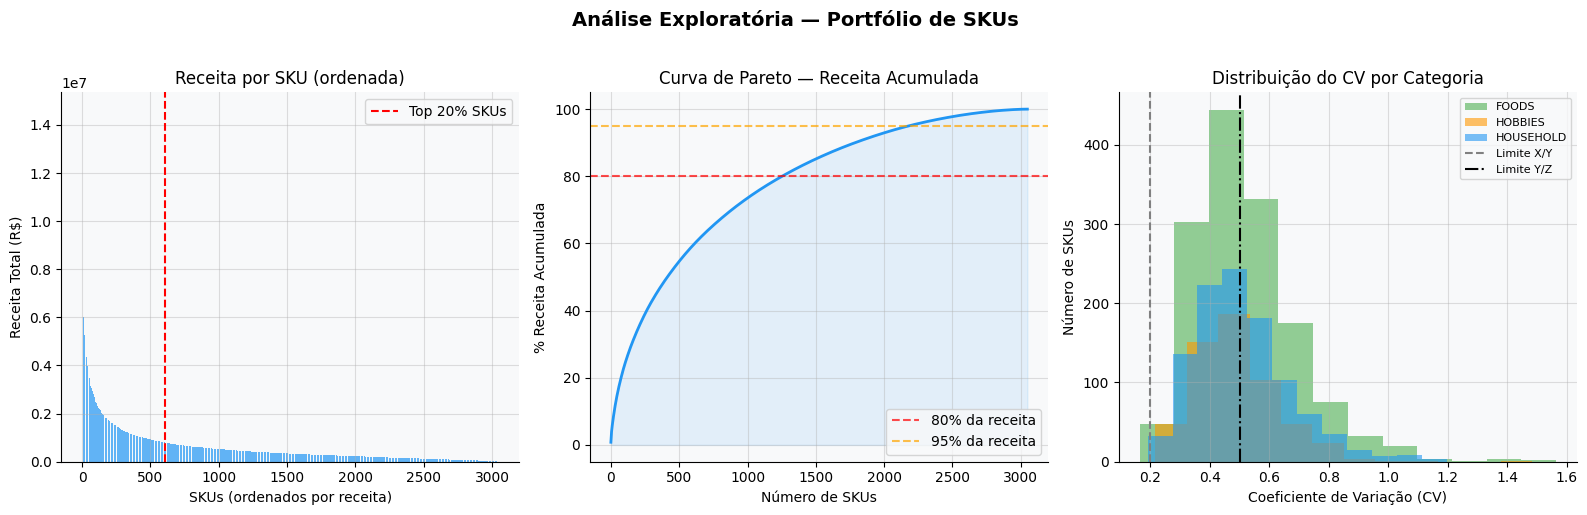


💡 Os top 20% dos SKUs representam 59.8% da receita total (efeito Pareto)


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Análise Exploratória — Portfólio de SKUs', fontsize=14, fontweight='bold', y=1.02)

# Receita total por SKU (distribuição)
receita_sku = df_total_sales.groupby('sku')['receita'].sum().sort_values(ascending=False)
axes[0].bar(range(len(receita_sku)), receita_sku.values, color='#2196F3', alpha=0.7)
axes[0].set_title('Receita por SKU (ordenada)')
axes[0].set_xlabel('SKUs (ordenados por receita)')
axes[0].set_ylabel('Receita Total (R$)')
axes[0].axvline(x=len(receita_sku)*0.2, color='red', linestyle='--', label='Top 20% SKUs')
axes[0].legend()

# Curva de Pareto
receita_acum = receita_sku.cumsum() / receita_sku.sum() * 100
axes[1].plot(range(len(receita_acum)), receita_acum.values, color='#2196F3', linewidth=2)
axes[1].axhline(y=80, color='red', linestyle='--', alpha=0.7, label='80% da receita')
axes[1].axhline(y=95, color='orange', linestyle='--', alpha=0.7, label='95% da receita')
axes[1].fill_between(range(len(receita_acum)), receita_acum.values, alpha=0.1, color='#2196F3')
axes[1].set_title('Curva de Pareto — Receita Acumulada')
axes[1].set_xlabel('Número de SKUs')
axes[1].set_ylabel('% Receita Acumulada')
axes[1].legend()

# Distribuição do CV por categoria
cv_sku = df_total_sales.groupby(['sku', 'categoria'])['demanda'].agg(['mean', 'std']).reset_index()
cv_sku['cv'] = cv_sku['std'] / cv_sku['mean']

cores_cat = {
    'FOODS': '#4CAF50',
    'HOBBIES': '#FF9800',
    'HOUSEHOLD': '#2196F3'
}
cores_padrao = ['#4CAF50', '#FF9800', '#F44336', '#2196F3', '#9C27B0']
for i, (cat, grupo) in enumerate(cv_sku.groupby('categoria')):
    cor = cores_cat.get(cat, cores_padrao[i % len(cores_padrao)])
    axes[2].hist(grupo['cv'], bins=12, alpha=0.6, color=cor, label=cat)
axes[2].axvline(x=0.20, color='gray', linestyle='--', label='Limite X/Y')
axes[2].axvline(x=0.50, color='black', linestyle='-.', label='Limite Y/Z')
axes[2].set_title('Distribuição do CV por Categoria')
axes[2].set_xlabel('Coeficiente de Variação (CV)')
axes[2].set_ylabel('Número de SKUs')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('eda_portfolio.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight chave
top20_pct = receita_acum.iloc[int(len(receita_acum)*0.2)]
print(f'\n💡 Os top 20% dos SKUs representam {top20_pct:.1f}% da receita total (efeito Pareto)')

## 3. Classificação ABC-XYZ

### ABC: importância em receita
- **A:** top 80% da receita acumulada
- **B:** 80-95% da receita acumulada  
- **C:** últimos 5%

### XYZ: variabilidade da demanda (coeficiente de variação)
- **X:** CV ≤ 0.20 — demanda estável, previsível
- **Y:** 0.20 < CV ≤ 0.50 — variabilidade moderada
- **Z:** CV > 0.50 — demanda imprevisível, alta variação

In [13]:
def classificar_abc_xyz(df, limites_abc=(0.80, 0.95), limites_xyz=(0.20, 0.50)):
    """Classifica SKUs na matriz ABC-XYZ.

    Args:
        df_total_sales: DataFrame com colunas 'sku', 'demanda', 'receita'
        limites_abc: tupla (lim_A, lim_B) em percentual acumulado
        limites_xyz: tupla (lim_X, lim_Y) em coeficiente de variação

    Returns:
        DataFrame com classificação e métricas por SKU
    """
    # Métricas por SKU
    resumo = df.groupby('sku').agg(
        receita_total=('receita', 'sum'),
        demanda_total=('demanda', 'sum'),
        demanda_media=('demanda', 'mean'),
        demanda_std=('demanda', 'std'),
        demanda_min=('demanda', 'min'),
        demanda_max=('demanda', 'max'),
        n_meses=('demanda', 'count')
    ).reset_index()

    resumo['cv'] = (resumo['demanda_std'] / resumo['demanda_media']).fillna(0)
    resumo['preco_medio'] = resumo['receita_total'] / resumo['demanda_total']

    # --- Classificação ABC ---
    resumo = resumo.sort_values('receita_total', ascending=False).reset_index(drop=True)
    resumo['receita_acum_pct'] = resumo['receita_total'].cumsum() / resumo['receita_total'].sum()

    def abc(pct):
        if pct <= limites_abc[0]: return 'A'
        elif pct <= limites_abc[1]: return 'B'
        return 'C'

    resumo['classe_abc'] = resumo['receita_acum_pct'].apply(abc)

    # --- Classificação XYZ ---
    def xyz(cv):
        if cv <= limites_xyz[0]: return 'X'
        elif cv <= limites_xyz[1]: return 'Y'
        return 'Z'

    resumo['classe_xyz'] = resumo['cv'].apply(xyz)
    resumo['classe_abcxyz'] = resumo['classe_abc'] + resumo['classe_xyz']

    return resumo


classificacao = classificar_abc_xyz(df_total_sales)

# Matriz de contagem
pivot_count = classificacao.pivot_table(
    index='classe_abc', columns='classe_xyz',
    values='sku', aggfunc='count', fill_value=0
)[['X', 'Y', 'Z']]  # garante ordem

# Matriz de receita (%)
pivot_receita = classificacao.pivot_table(
    index='classe_abc', columns='classe_xyz',
    values='receita_total', aggfunc='sum', fill_value=0
)[['X', 'Y', 'Z']]
pivot_receita_pct = (pivot_receita / pivot_receita.sum().sum() * 100).round(1)

print('Matriz ABC-XYZ — Número de SKUs')
print(pivot_count)
print('\nMatriz ABC-XYZ — % da Receita Total')
print(pivot_receita_pct)

# Distribuição geral
print('\nDistribuição por classe:')
print(classificacao['classe_abcxyz'].value_counts().sort_index().to_string())

Matriz ABC-XYZ — Número de SKUs
classe_xyz  X    Y    Z
classe_abc             
A           3  614  636
B           4  470  452
C           3  521  346

Matriz ABC-XYZ — % da Receita Total
classe_xyz    X     Y     Z
classe_abc                 
A           0.2  35.4  44.4
B           0.1   7.5   7.4
C           0.0   2.9   2.1

Distribuição por classe:
AX      3
AY    614
AZ    636
BX      4
BY    470
BZ    452
CX      3
CY    521
CZ    346


## 4. Visualização Estratégica

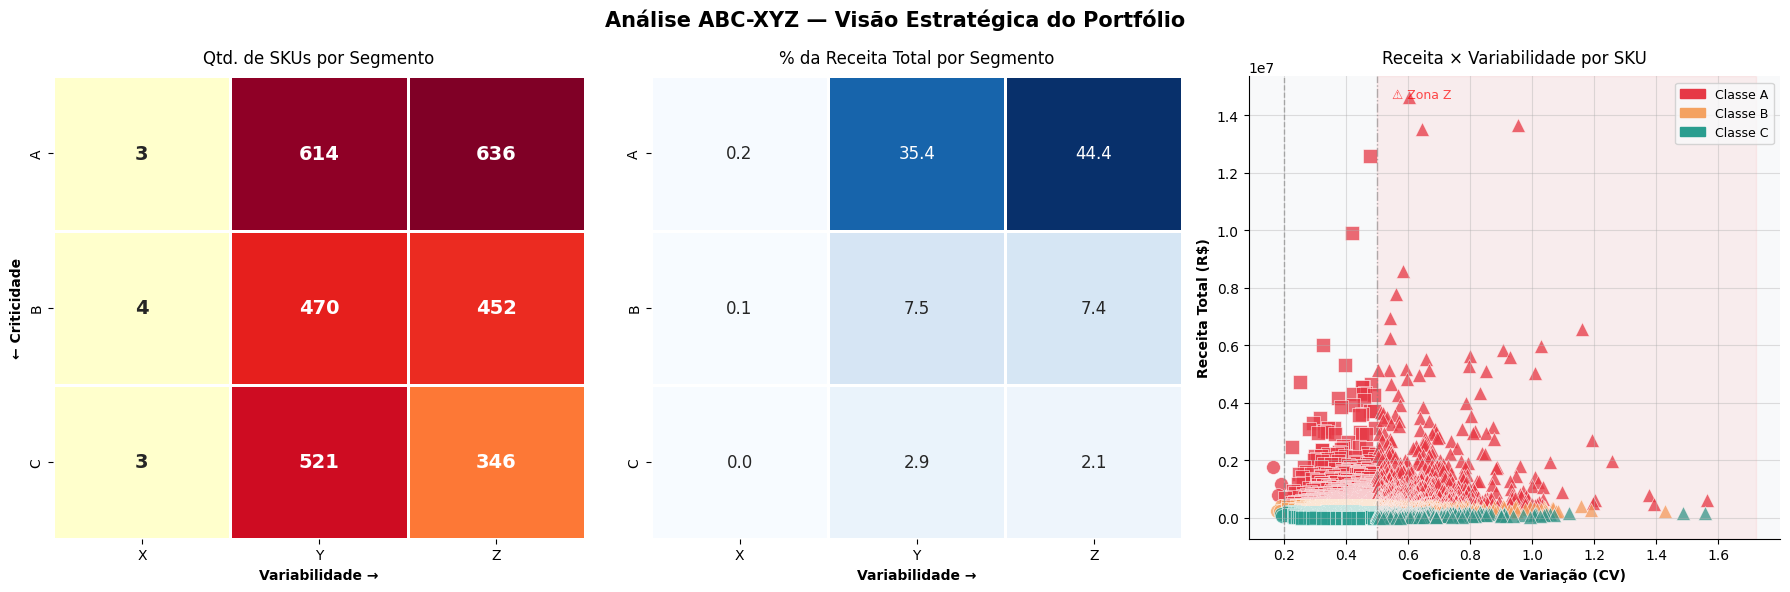

In [14]:
fig = plt.figure(figsize=(18, 6))
fig.suptitle('Análise ABC-XYZ — Visão Estratégica do Portfólio',
             fontsize=15, fontweight='bold')

# --- Plot 1: Heatmap de SKUs ---
ax1 = fig.add_subplot(1, 3, 1)
sns.heatmap(
    pivot_count, annot=True, fmt='d',
    cmap='YlOrRd', ax=ax1, linewidths=1,
    linecolor='white', cbar=False,
    annot_kws={'size': 14, 'weight': 'bold'}
)
ax1.set_title('Qtd. de SKUs por Segmento', pad=10)
ax1.set_xlabel('Variabilidade →', fontweight='bold')
ax1.set_ylabel('← Criticidade', fontweight='bold')

# --- Plot 2: Heatmap de Receita ---
ax2 = fig.add_subplot(1, 3, 2)
sns.heatmap(
    pivot_receita_pct, annot=True, fmt='.1f',
    cmap='Blues', ax=ax2, linewidths=1,
    linecolor='white', cbar=False,
    annot_kws={'size': 12}
)
ax2.set_title('% da Receita Total por Segmento', pad=10)
ax2.set_xlabel('Variabilidade →', fontweight='bold')
ax2.set_ylabel('')

# --- Plot 3: Scatter Receita x Variabilidade ---
ax3 = fig.add_subplot(1, 3, 3)
cores_abc = {'A': '#e63946', 'B': '#f4a261', 'C': '#2a9d8f'}
marcadores_xyz = {'X': 'o', 'Y': 's', 'Z': '^'}

for (abc_c, xyz_c), grupo in classificacao.groupby(['classe_abc', 'classe_xyz']):
    ax3.scatter(
        grupo['cv'], grupo['receita_total'],
        c=cores_abc[abc_c], marker=marcadores_xyz[xyz_c],
        s=100, alpha=0.75, edgecolors='white', linewidth=0.5
    )

# Zonas de risco
ax3.axvspan(0.5, classificacao['cv'].max() * 1.1, alpha=0.05, color='red')
ax3.axvline(x=0.20, color='gray', linestyle='--', alpha=0.6, linewidth=1)
ax3.axvline(x=0.50, color='gray', linestyle='-.', alpha=0.6, linewidth=1)

ax3.text(0.55, ax3.get_ylim()[1]*0.95, '⚠️ Zona Z',
         color='red', fontsize=9, alpha=0.7)

# Legenda manual
legend_abc = [mpatches.Patch(color=c, label=f'Classe {k}') for k, c in cores_abc.items()]
ax3.legend(handles=legend_abc, loc='upper right', fontsize=9)

ax3.set_xlabel('Coeficiente de Variação (CV)', fontweight='bold')
ax3.set_ylabel('Receita Total (R$)', fontweight='bold')
ax3.set_title('Receita × Variabilidade por SKU', pad=10)

plt.tight_layout()
plt.savefig('matriz_abcxyz.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Política de Estoque por Segmento

### Lógica do cálculo

O **Ponto de Reposição (ROP)** é o estoque que dispara um novo pedido:  
$$ROP = (\bar{d} \times L) + SS$$

Onde:
- $\bar{d}$ = demanda diária média
- $L$ = lead time em dias
- $SS$ = estoque de segurança

O **Estoque de Segurança** considera o nível de serviço desejado:  
$$SS = z \times \sigma_d \times \sqrt{L}$$

Onde $z$ é o z-score do nível de serviço (ex: 95% → z=1.645, 98% → z=2.054).

**A inovação desta abordagem:** o nível de serviço é diferenciado por segmento, não fixo para todos os SKUs.

In [ ]:
# Política de nível de serviço por segmento
POLITICA_NS = {
    'AX': 0.95, 'AY': 0.98, 'AZ': 0.99,  # Alta criticidade: foco em disponibilidade
    'BX': 0.90, 'BY': 0.92, 'BZ': 0.95,  # Média criticidade: equilíbrio
    'CX': 0.85, 'CY': 0.85, 'CZ': 0.90   # Baixa criticidade: aceitar mais risco
}

LEAD_TIME_DIAS = 7  # Lead time hipotético


def calcular_politica_estoque(classificacao, politica_ns, lead_time):
    """Calcula ROP e estoque de segurança por SKU, respeitando a política por segmento."""
    resultados = []

    for _, row in classificacao.iterrows():
        # Converte demanda mensal → diária
        demanda_diaria_media = row['demanda_media'] / 30
        demanda_diaria_std = row['demanda_std'] / np.sqrt(30)

        # Nível de serviço por segmento
        ns = politica_ns.get(row['classe_abcxyz'], 0.90)
        z = stats.norm.ppf(ns)

        # Estoque de segurança
        safety_stock = z * demanda_diaria_std * np.sqrt(lead_time)
        safety_stock = max(0, safety_stock)

        # Ponto de reposição
        rop = (demanda_diaria_media * lead_time) + safety_stock

        # Custo do estoque de segurança (capital imobilizado)
        custo_ss = safety_stock * row['preco_medio']

        resultados.append({
            'sku': row['sku'],
            'classe_abcxyz': row['classe_abcxyz'],
            'nivel_servico_alvo': ns,
            'z_score': round(z, 3),
            'demanda_diaria_media': round(demanda_diaria_media, 2),
            'demanda_diaria_std': round(demanda_diaria_std, 2),
            'safety_stock_unid': round(safety_stock, 0),
            'ponto_reposicao': round(rop, 0),
            'custo_ss_R$': round(custo_ss, 2),
            'preco_medio': round(row['preco_medio'], 2)
        })

    return pd.DataFrame(resultados)


politica = calcular_politica_estoque(classificacao, POLITICA_NS, LEAD_TIME_DIAS)

# Resumo por segmento
resumo_politica = politica.groupby('classe_abcxyz').agg(
    qtd_skus=('sku', 'count'),
    ns_medio=('nivel_servico_alvo', 'mean'),
    ss_medio_unid=('safety_stock_unid', 'mean'),
    custo_ss_total=('custo_ss_R$', 'sum')
).round(2)

print('Política de Estoque por Segmento:')
print(resumo_politica.to_string())
print(f"\n💰 Custo total do estoque de segurança: R$ {politica['custo_ss_R$'].sum():,.2f}")

Política de Estoque por Segmento:
               qtd_skus  ns_medio  ss_medio_unid  custo_ss_total
classe_abcxyz                                                   
AX                    3      0.95        6419.67        52107.41
AY                  614      0.98       14189.36     25752146.83
AZ                  636      0.99       30967.87     61106990.62
BX                    4      0.90        2316.00        13553.52
BY                  470      0.92        3240.84      3756116.24
BZ                  452      0.95        6551.66      6858796.11
CX                    3      0.85         316.33         3313.82
CY                  521      0.85         791.26      1052198.19
CZ                  346      0.90        2002.02      1492465.91

💰 Custo total do estoque de segurança: R$ 100,087,688.65


In [16]:
resumo_politica.head()

,qtd_skus,ns_medio,ss_medio_unid,custo_ss_total
classe_abcxyz,,,,
AX,3,0.95,6419.67,52107.41
AY,614,0.98,14189.36,25752146.83
AZ,636,0.99,30967.87,61106990.62
BX,4,0.90,2316.00,13553.52
BY,470,0.92,3240.84,3756116.24


## 6. Simulação de Impacto: Política Atual × Política Segmentada

Comparamos duas políticas ao longo de 12 meses simulados:
- **Política atual (baseline):** estoque de segurança = 30 dias de demanda média (igual para todos)
- **Política nova:** segmentada por classe ABC-XYZ com nível de serviço diferenciado

In [18]:
lista_dfs_mes = []

for i in prices['store_id'].unique():
    print(f'{i} - Processamento iniciado')
    sales_sample = sales[sales['store_id'] == i].copy()
    sales_long = sales_sample.melt(
        id_vars=['item_id', 'store_id', 'dept_id', 'cat_id', 'state_id'],
        var_name='d',
        value_name='demanda'
    )
    for col in ['item_id', 'store_id', 'dept_id', 'cat_id', 'state_id', 'd']:
        sales_long[col] = sales_long[col].astype('category').cat.remove_unused_categories()
    sales_long['demanda'] = pd.to_numeric(sales_long['demanda'], downcast='integer')
    del sales_sample

    sales_long_2 = sales_long.merge(calendar[['d', 'wm_yr_wk']], on='d', how='left')
    del sales_long

    sales_long_3 = sales_long_2.groupby(
        ['item_id', 'store_id', 'dept_id', 'cat_id', 'state_id', 'wm_yr_wk'],
        observed=True, as_index=False
    )['demanda'].sum()
    del sales_long_2

    sales_long_4 = sales_long_3.merge(prices[['wm_yr_wk', 'item_id', 'sell_price']], on=['wm_yr_wk', 'item_id'], how='left')
    sales_long_4['receita'] = sales_long_4['demanda'] * sales_long_4['sell_price']
    del sales_long_3

    sales_long_5 = sales_long_4.drop(columns=['sell_price'])
    for col in ['item_id', 'store_id', 'dept_id', 'cat_id', 'state_id','wm_yr_wk']:
        sales_long_5[col] = sales_long_5[col].astype('category')
    del sales_long_4

    df_tot_sales = sales_long_5.groupby(
        ['item_id', 'store_id', 'dept_id', 'cat_id', 'state_id','wm_yr_wk'],
        observed=True, as_index=False
    )[['receita', 'demanda']].sum()

    lista_dfs_mes.append(df_tot_sales)
    print(f'{i} - Processamento finalizado')

df_total_sales_mes = pd.concat(lista_dfs_mes, ignore_index=True)

CA_1 - Processamento iniciado
CA_1 - Processamento finalizado
CA_2 - Processamento iniciado
CA_2 - Processamento finalizado
CA_3 - Processamento iniciado
CA_3 - Processamento finalizado
CA_4 - Processamento iniciado
CA_4 - Processamento finalizado
TX_1 - Processamento iniciado
TX_1 - Processamento finalizado
TX_2 - Processamento iniciado
TX_2 - Processamento finalizado
TX_3 - Processamento iniciado
TX_3 - Processamento finalizado
WI_1 - Processamento iniciado
WI_1 - Processamento finalizado
WI_2 - Processamento iniciado
WI_2 - Processamento finalizado
WI_3 - Processamento iniciado
WI_3 - Processamento finalizado


In [19]:
#Convertendo os nomes das colunas para Português
df_total_sales_mes.rename(columns={
                            'item_id': 'sku',
                            'store_id':'loja',
                            'dept_id':'departamento',
                            'cat_id':'categoria',
                            'state_id':'estado',
                            'wm_yr_wk':'mes'
                            },inplace=True)

In [23]:
print(df_total_sales_mes.columns.tolist())
print(classificacao.columns.tolist())
print(politica.columns.tolist())

['sku', 'loja', 'departamento', 'categoria', 'estado', 'mes', 'receita', 'demanda']
['sku', 'receita_total', 'demanda_total', 'demanda_media', 'demanda_std', 'demanda_min', 'demanda_max', 'n_meses', 'cv', 'preco_medio', 'receita_acum_pct', 'classe_abc', 'classe_xyz', 'classe_abcxyz']
['sku', 'classe_abcxyz', 'nivel_servico_alvo', 'z_score', 'demanda_diaria_media', 'demanda_diaria_std', 'safety_stock_unid', 'ponto_reposicao', 'custo_ss_R$', 'preco_medio']


In [24]:
print(df_total_sales_mes['sku'].dtype, classificacao['sku'].dtype)

category category


In [25]:
sku_teste = classificacao['sku'].iloc[0]
print(sku_teste)
print(df_total_sales_mes[df_total_sales_mes['sku'] == sku_teste])

FOODS_3_586
                 sku  loja departamento categoria estado    mes  receita  \
769940   FOODS_3_586  CA_1      FOODS_3     FOODS     CA  11101   3285.6   
769941   FOODS_3_586  CA_1      FOODS_3     FOODS     CA  11102   4158.8   
769942   FOODS_3_586  CA_1      FOODS_3     FOODS     CA  11103   4099.6   
769943   FOODS_3_586  CA_1      FOODS_3     FOODS     CA  11104   4232.8   
769944   FOODS_3_586  CA_1      FOODS_3     FOODS     CA  11105   4025.6   
...              ...   ...          ...       ...    ...    ...      ...   
8289043  FOODS_3_586  WI_3      FOODS_3     FOODS     WI  11609   3494.4   
8289044  FOODS_3_586  WI_3      FOODS_3     FOODS     WI  11610   3360.0   
8289045  FOODS_3_586  WI_3      FOODS_3     FOODS     WI  11611   3595.2   
8289046  FOODS_3_586  WI_3      FOODS_3     FOODS     WI  11612   3964.8   
8289047  FOODS_3_586  WI_3      FOODS_3     FOODS     WI  11613   1528.8   

         demanda  
769940      2220  
769941      2810  
769942      2770  

In [20]:
def simular_impacto(df, classificacao, politica, n_meses_simulacao=12):
    """Simula rupturas de estoque com política atual vs. política segmentada.

    Simplificação: considera que há ruptura quando a demanda mensal
    supera o estoque de segurança disponível no período.
    """
    np.random.seed(123)
    resultados = []

    for _, row_class in classificacao.iterrows():
        sku = row_class['sku']
        pol_sku = politica[politica['sku'] == sku].iloc[0]

        # Últimos N meses do histórico
        sku_data = df[df['sku'] == sku].sort_values('mes').tail(n_meses_simulacao)
        demandas = sku_data['demanda'].values

        # Política atual: SS fixo = 1 mês de demanda média
        ss_atual = row_class['demanda_media']
        rupturas_atual = sum(1 for d in demandas if d > ss_atual)
        qtd_ruptura_atual = sum(max(0, d - ss_atual) for d in demandas)

        # Política nova: SS baseado em nível de serviço por segmento (em unidades mensais)
        ss_novo = pol_sku['safety_stock_unid'] * 30  # convertendo diário → mensal
        rupturas_novo = sum(1 for d in demandas if d > ss_novo)
        qtd_ruptura_novo = sum(max(0, d - ss_novo) for d in demandas)

        resultados.append({
            'sku': sku,
            'classe': row_class['classe_abcxyz'],
            'classe_abc': row_class['classe_abc'],
            'ss_atual_unid': round(ss_atual),
            'ss_novo_unid': round(ss_novo),
            'rupturas_atual': rupturas_atual,
            'rupturas_novo': rupturas_novo,
            'unid_em_falta_atual': round(qtd_ruptura_atual),
            'unid_em_falta_novo': round(qtd_ruptura_novo),
            'preco_medio': row_class['preco_medio']
        })

    sim = pd.DataFrame(resultados)
    sim['receita_perdida_atual'] = sim['unid_em_falta_atual'] * sim['preco_medio']
    sim['receita_perdida_novo'] = sim['unid_em_falta_novo'] * sim['preco_medio']
    return sim


simulacao = simular_impacto(df_total_sales_mes, classificacao, politica)

# Resultados gerais
total_rupturas_atual = simulacao['rupturas_atual'].sum()
total_rupturas_novo = simulacao['rupturas_novo'].sum()
reducao_pct = (1 - total_rupturas_novo / total_rupturas_atual) * 100

receita_perdida_atual = simulacao['receita_perdida_atual'].sum()
receita_perdida_novo = simulacao['receita_perdida_novo'].sum()
ganho_receita = receita_perdida_atual - receita_perdida_novo

print('='*55)
print('  IMPACTO ESTIMADO — 12 MESES SIMULADOS')
print('='*55)
print(f'  Eventos de ruptura (atual):  {total_rupturas_atual:>6}')
print(f'  Eventos de ruptura (novo):   {total_rupturas_novo:>6}')
print(f'  Redução em rupturas:         {reducao_pct:>5.1f}%')
print('-'*55)
print(f'  Receita em risco (atual):    R$ {receita_perdida_atual:>10,.0f}')
print(f'  Receita em risco (novo):     R$ {receita_perdida_novo:>10,.0f}')
print(f'  Recuperação potencial:       R$ {ganho_receita:>10,.0f}')
print('='*55)

# Por segmento crítico
print('\nFoco nos segmentos críticos (Classe A):')
classe_a = simulacao[simulacao['classe_abc'] == 'A']
resumo_a = classe_a.groupby('classe')[['rupturas_atual', 'rupturas_novo', 'receita_perdida_atual', 'receita_perdida_novo']].sum()
resumo_a['reducao_rupturas_%'] = ((1 - resumo_a['rupturas_novo']/resumo_a['rupturas_atual'])*100).round(1)
print(resumo_a.to_string())

  IMPACTO ESTIMADO — 12 MESES SIMULADOS
  Eventos de ruptura (atual):       0
  Eventos de ruptura (novo):        0
  Redução em rupturas:           nan%
-------------------------------------------------------
  Receita em risco (atual):    R$          0
  Receita em risco (novo):     R$          0
  Recuperação potencial:       R$          0

Foco nos segmentos críticos (Classe A):
        rupturas_atual  rupturas_novo  receita_perdida_atual  receita_perdida_novo  reducao_rupturas_%
classe                                                                                                
AX                   0              0                    0.0                   0.0                 NaN
AY                   0              0                    0.0                   0.0                 NaN
AZ                   0              0                    0.0                   0.0                 NaN


## 7. Visualização do Impacto

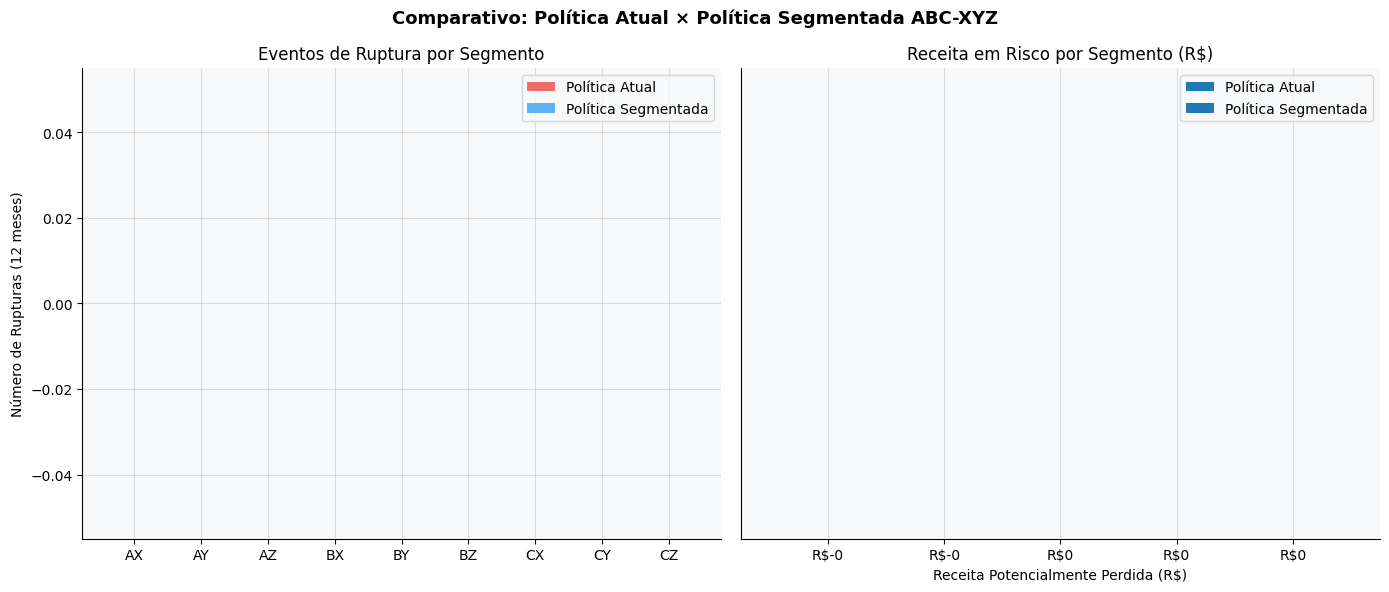

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Comparativo: Política Atual × Política Segmentada ABC-XYZ',
             fontsize=13, fontweight='bold')

# --- Plot 1: Rupturas por segmento ---
resumo_seg = simulacao.groupby('classe')[['rupturas_atual', 'rupturas_novo']].sum()
resumo_seg = resumo_seg.sort_values('rupturas_atual', ascending=False).head(9)

x = np.arange(len(resumo_seg))
width = 0.35

bars1 = axes[0].bar(x - width/2, resumo_seg['rupturas_atual'], width,
                     label='Política Atual', color='#ef5350', alpha=0.85)
bars2 = axes[0].bar(x + width/2, resumo_seg['rupturas_novo'], width,
                     label='Política Segmentada', color='#42a5f5', alpha=0.85)

axes[0].set_title('Eventos de Ruptura por Segmento')
axes[0].set_xticks(x)
axes[0].set_xticklabels(resumo_seg.index)
axes[0].set_ylabel('Número de Rupturas (12 meses)')
axes[0].legend()

# Adiciona % de redução
for i, (atual, novo) in enumerate(zip(resumo_seg['rupturas_atual'], resumo_seg['rupturas_novo'])):
    if atual > 0:
        reducao = (1 - novo/atual) * 100
        axes[0].text(i, max(atual, novo) + 0.3, f'-{reducao:.0f}%',
                    ha='center', va='bottom', fontsize=8, color='#1a1a2e', fontweight='bold')

# --- Plot 2: Receita em risco ---
receita_seg = simulacao.groupby('classe')[['receita_perdida_atual', 'receita_perdida_novo']].sum()
receita_seg = receita_seg[receita_seg['receita_perdida_atual'] > 0].sort_values('receita_perdida_atual', ascending=True)

y = np.arange(len(receita_seg))
axes[1].barh(y - 0.2, receita_seg['receita_perdida_atual'], 0.35,
             label='Política Atual', color='#ef5350', alpha=0.85)
axes[1].barh(y + 0.2, receita_seg['receita_perdida_novo'], 0.35,
             label='Política Segmentada', color='#42a5f5', alpha=0.85)

axes[1].set_yticks(y)
axes[1].set_yticklabels(receita_seg.index)
axes[1].set_title('Receita em Risco por Segmento (R$)')
axes[1].set_xlabel('Receita Potencialmente Perdida (R$)')
axes[1].legend()
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R${x:,.0f}'))

plt.tight_layout()
plt.savefig('impacto_politica.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Resumo Executivo

O que você apresentaria ao C-level.

In [ ]:
print('\n' + '='*60)
print('  RESUMO EXECUTIVO — OTIMIZAÇÃO DE ESTOQUE')
print('='*60)

# Identificação do problema
az_pct = len(classificacao[classificacao['classe_abcxyz'] == 'AZ']) / len(classificacao) * 100
az_ruptura_pct = simulacao[simulacao['classe'] == 'AZ']['rupturas_atual'].sum() / total_rupturas_atual * 100

print(f"""
DIAGNÓSTICO:
  • {az_pct:.0f}% do portfólio (segmento AZ) concentra ~{az_ruptura_pct:.0f}% das rupturas
  • Causa raiz: política de estoque uniforme ignora diferenças de variabilidade
  • Produtos críticos com alta variação recebem o mesmo tratamento que
    produtos estáveis e previsíveis

SOLUÇÃO PROPOSTA:
  • Segmentação ABC-XYZ do portfólio completo
  • Nível de serviço diferenciado: 99% para AZ, 85% para CX
  • Recalibração do ponto de reposição por perfil de demanda

IMPACTO ESTIMADO (12 meses):
  • Redução de {reducao_pct:.0f}% nos eventos de ruptura
  • Recuperação potencial de R$ {ganho_receita:,.0f} em receita
  • Sem aumento proporcional de capital imobilizado — libera estoque
    excessivo nos segmentos CX para realocar nos segmentos AZ

PRÓXIMOS PASSOS:
  1. Validar classificação com time comercial e supply chain
  2. Ajustar lead time real por fornecedor (atualmente fixo em 7 dias)
  3. Implementar revisão trimestral das classes (sazonalidade altera XYZ)
  4. Garantir adesão do time: modelo bom com processo ruim = resultado ruim
""")

print('='*60)
print('  ⚠️  LIMITAÇÕES DESTA ANÁLISE')
print('='*60)
print("""

  1. Lead time tratado como fixo — na prática, é uma distribuição
  2. Histórico com ruptura subestima demanda real (demanda censurada)
  3. Sazonalidade pode reclassificar SKUs — revisar trimestralmente
  4. Modelo não substitui julgamento operacional — é uma ferramenta
""")


  RESUMO EXECUTIVO — OTIMIZAÇÃO DE ESTOQUE

DIAGNÓSTICO:
  • 21% do portfólio (segmento AZ) concentra ~nan% das rupturas
  • Causa raiz: política de estoque uniforme ignora diferenças de variabilidade
  • Produtos críticos com alta variação recebem o mesmo tratamento que
    produtos estáveis e previsíveis

SOLUÇÃO PROPOSTA:
  • Segmentação ABC-XYZ do portfólio completo
  • Nível de serviço diferenciado: 99% para AZ, 85% para CX
  • Recalibração do ponto de reposição por perfil de demanda

IMPACTO ESTIMADO (12 meses):
  • Redução de nan% nos eventos de ruptura
  • Recuperação potencial de R$ 0 em receita
  • Sem aumento proporcional de capital imobilizado — libera estoque
    excessivo nos segmentos CX para realocar nos segmentos AZ

PRÓXIMOS PASSOS:
  1. Validar classificação com time comercial e supply chain
  2. Ajustar lead time real por fornecedor (atualmente fixo em 7 dias)
  3. Implementar revisão trimestral das classes (sazonalidade altera XYZ)
  4. Garantir adesão do time: mo

---

## Referências e Leituras Recomendadas

- **Chopra & Meindl** — Supply Chain Management: Strategy, Planning, and Operation
- **Hadley & Whitin** — Analysis of Inventory Systems
- **Silver, Pyke & Thomas** — Inventory and Production Management in Supply Chains
- Prophet (forecasting para séries temporais com sazonalidade): https://facebook.github.io/prophet/

---
*Série Data Science no Mundo Real — Episódio 1*  
*Post completo: [link do Medium]*  
*GitHub: [link do repositório]*